In [291]:
# Uncomment if required

# !pip install pandas numpy matplotlib seaborn plotly scikit-learn

In [292]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Plot Settings
plt.style.use('ggplot')
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [293]:
clients = pd.read_csv('/content/clients.csv')
properties = pd.read_csv('/content/properties.csv')

print("Clients Dataset Shape :", clients.shape)
print("Properties Dataset Shape :", properties.shape)

Clients Dataset Shape : (2000, 12)
Properties Dataset Shape : (10000, 9)


In [294]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [295]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [296]:
print("Clients Dataset Information")
print("-"*50)

clients.info()

print("\n")

print("Properties Dataset Information")
print("-"*50)

properties.info()

Clients Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


Properties Dataset Information
------------------------------------------

In [297]:
clients.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,2000,2000,C1984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_type,2000,2,Individual,1897,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_name,2000,337,Carl,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,2000,224,Co,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_birth,2000,1889,4/13/1967,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,2000,2,M,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,2000,10,USA,1538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,2000,57,California,633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_purpose,2000,2,Home,1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satisfaction_score,2000.0,NaN,NaN,NaN,3.029,1.413562,1.0,2.0,3.0,4.0,5.0


In [298]:
properties.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
listing_id,10000.0,NaN,NaN,NaN,105898.2774,74414.566199,1002.0,50389.75,100404.5,150411.25,990026.0
tower_number,10000.0,NaN,NaN,NaN,10.3701,5.769025,1.0,5.0,10.0,15.0,20.0
transaction_date,10000,24,06-01-2024,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_category,10000,2,Apartment,8547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_number,10000.0,NaN,NaN,NaN,28.9992,16.88242,1.0,15.0,29.0,43.0,70.0
floor_area_sqft,10000.0,NaN,NaN,NaN,1139.941412,418.373967,410.71,782.2,1110.88,1499.0,1957.16
sale_price,10000,9998,"$342,414.51",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listing_status,10000,2,Sold,7305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_ref,7305,2000,C0005,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [299]:
print("Clients Missing Values")

clients.isnull().sum()

Clients Missing Values


,0
client_id,0
client_type,0
first_name,0
last_name,0
date_of_birth,0
gender,0
country,0
region,0
acquisition_purpose,0
satisfaction_score,0


In [300]:
print("Properties Missing Values")

properties.isnull().sum()

Properties Missing Values


,0
listing_id,0
tower_number,0
transaction_date,0
unit_category,0
unit_number,0
floor_area_sqft,0
sale_price,0
listing_status,0
client_ref,2695


In [301]:
missing = clients.isnull().sum()

missing = pd.DataFrame({

    "Missing Values":missing,

    "Percentage":(missing/len(clients))*100

})

missing.sort_values(by="Percentage",ascending=False)

,Missing Values,Percentage
client_id,0,0.0
client_type,0,0.0
first_name,0,0.0
last_name,0,0.0
date_of_birth,0,0.0
gender,0,0.0
country,0,0.0
region,0,0.0
acquisition_purpose,0,0.0
satisfaction_score,0,0.0


In [302]:
print("Duplicate Records in Clients :",clients.duplicated().sum())

print("Duplicate Records in Properties :",properties.duplicated().sum())

Duplicate Records in Clients : 0
Duplicate Records in Properties : 0


In [303]:
clients.drop_duplicates(inplace=True)

properties.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [304]:
num_cols = clients.select_dtypes(include=np.number).columns

clients[num_cols] = clients[num_cols].fillna(clients[num_cols].median())

In [305]:
cat_cols = clients.select_dtypes(include='object').columns

for col in cat_cols:
    clients[col].fillna(clients[col].mode()[0], inplace=True)

In [306]:
num_cols = properties.select_dtypes(include=np.number).columns

properties[num_cols] = properties[num_cols].fillna(properties[num_cols].median())

cat_cols = properties.select_dtypes(include='object').columns

for col in cat_cols:

    properties[col].fillna(properties[col].mode()[0], inplace=True)

In [307]:
clients.isnull().sum()

,0
client_id,0
client_type,0
first_name,0
last_name,0
date_of_birth,0
gender,0
country,0
region,0
acquisition_purpose,0
satisfaction_score,0


In [308]:
properties.isnull().sum()

,0
listing_id,0
tower_number,0
transaction_date,0
unit_category,0
unit_number,0
floor_area_sqft,0
sale_price,0
listing_status,0
client_ref,0


In [309]:
print("Clients Columns")

print(clients.columns.tolist())

Clients Columns
['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel']


In [310]:
print("Properties Columns")

print(properties.columns.tolist())

Properties Columns
['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']


In [311]:
data = pd.merge(
    clients,
    properties,
    left_on="client_id",
    right_on="client_ref",
    how="inner"
)

print("Merged Dataset Shape :", data.shape)

Merged Dataset Shape : (10000, 21)


In [312]:
data.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,"$351,419.29",Sold,C0001
1,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,"$496,266.41",Sold,C0001
2,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,"$175,599.90",Sold,C0001
3,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,"$223,479.12",Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,"$299,245.20",Sold,C0002


In [313]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            10000 non-null  object 
 1   client_type          10000 non-null  object 
 2   first_name           10000 non-null  object 
 3   last_name            10000 non-null  object 
 4   date_of_birth        10000 non-null  object 
 5   gender               10000 non-null  object 
 6   country              10000 non-null  object 
 7   region               10000 non-null  object 
 8   acquisition_purpose  10000 non-null  object 
 9   satisfaction_score   10000 non-null  int64  
 10  loan_applied         10000 non-null  object 
 11  referral_channel     10000 non-null  object 
 12  listing_id           10000 non-null  int64  
 13  tower_number         10000 non-null  int64  
 14  transaction_date     10000 non-null  object 
 15  unit_category        10000 non-null  

In [314]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,10000,2000,C0005,2708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_type,10000,2,Individual,6924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_name,10000,337,Marleez,2708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,10000,224,Co,3076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_birth,10000,1889,2/28/1976,2708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,M,6418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,10000,10,USA,8351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,10000,57,California,5094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_purpose,10000,2,Home,5058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
satisfaction_score,10000.0,NaN,NaN,NaN,3.5768,1.487321,1.0,2.0,4.0,5.0,5.0


In [315]:
print("Rows :",data.shape[0])

print("Columns :",data.shape[1])

Rows : 10000
Columns : 21


In [316]:
data.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel', 'listing_id',
       'tower_number', 'transaction_date', 'unit_category', 'unit_number',
       'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref'],
      dtype='object')

In [317]:
data.dtypes

,0
client_id,object
client_type,object
first_name,object
last_name,object
date_of_birth,object
gender,object
country,object
region,object
acquisition_purpose,object
satisfaction_score,int64


In [318]:
data.select_dtypes(include=np.number).columns

Index(['satisfaction_score', 'listing_id', 'tower_number', 'unit_number',
       'floor_area_sqft'],
      dtype='object')

In [319]:
data.select_dtypes(include='object').columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied',
       'referral_channel', 'transaction_date', 'unit_category', 'sale_price',
       'listing_status', 'client_ref'],
      dtype='object')

In [320]:
for col in data.select_dtypes(include='object'):

    print("="*50)

    print(col)

    print(data[col].value_counts())

    print()

client_id
client_id
C0005    2708
C0007      11
C0026      10
C0161       9
C0050       9
         ... 
C1060       3
C1059       3
C2000       3
C1999       3
C1998       3
Name: count, Length: 2000, dtype: int64

client_type
client_type
Individual    6924
Company       3076
Name: count, dtype: int64

first_name
first_name
Marleez    2708
Carl         87
Sarah        77
William      70
Gerald       69
           ... 
Jace          4
Polaris       3
Apex          3
Nexus         3
Halcyon       3
Name: count, Length: 337, dtype: int64

last_name
last_name
Co         3076
Howard      134
Hansen      128
Turner      112
Morales     112
           ... 
Juarez        4
Pugh          4
Crane         4
Stout         4
Simmons       4
Name: count, Length: 224, dtype: int64

date_of_birth
date_of_birth
2/28/1976     2708
12-02-1971      13
4/13/1967       12
11-12-1995      12
10/24/1973      11
              ... 
10/28/1980       3
07-10-1954       3
06-10-1962       3
6/26/1951        3
6/13

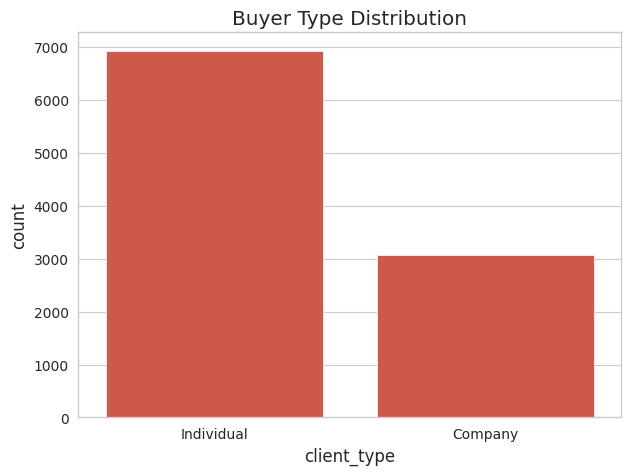

In [321]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=data,
    x='client_type'
)

plt.title("Buyer Type Distribution")

plt.show()

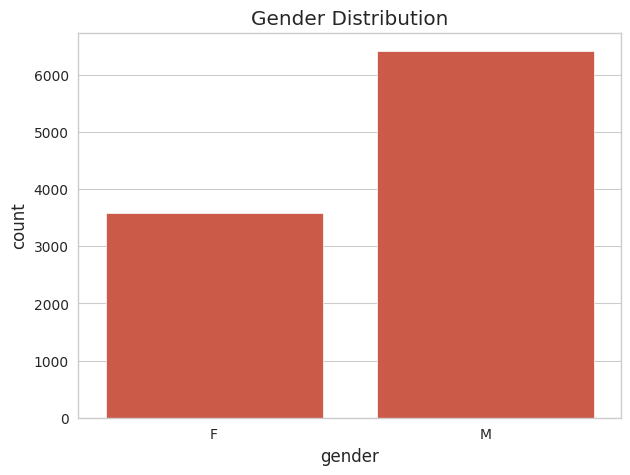

In [322]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=data,
    x='gender'
)

plt.title("Gender Distribution")

plt.show()

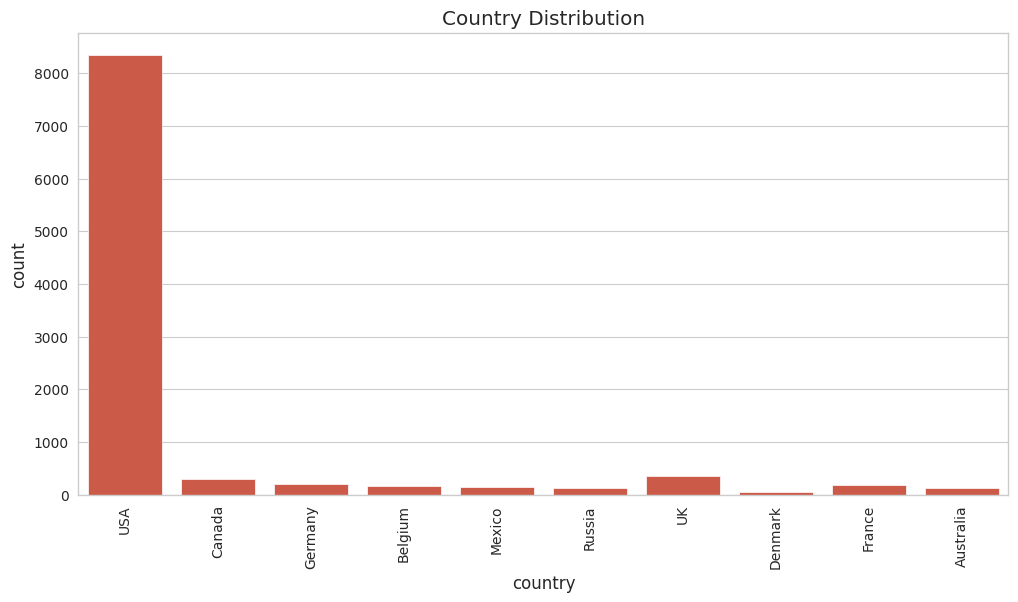

In [323]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x='country'
)

plt.xticks(rotation=90)

plt.title("Country Distribution")

plt.show()

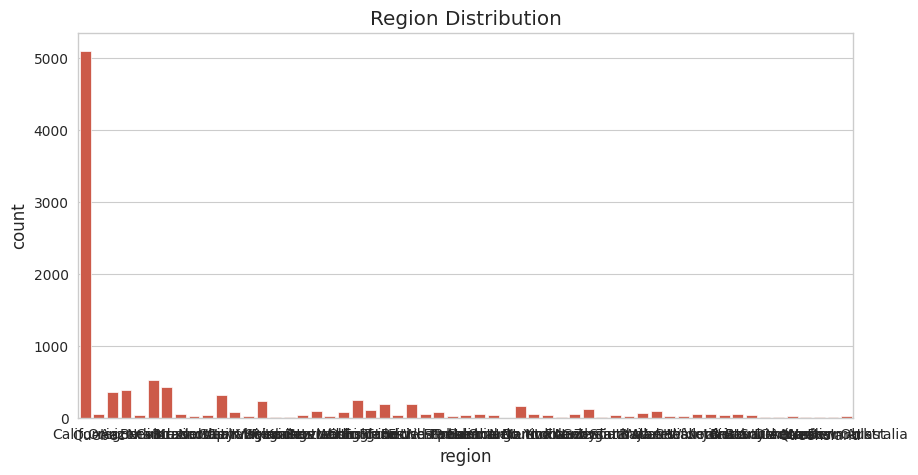

In [324]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x='region'
)

plt.title("Region Distribution")

plt.show()

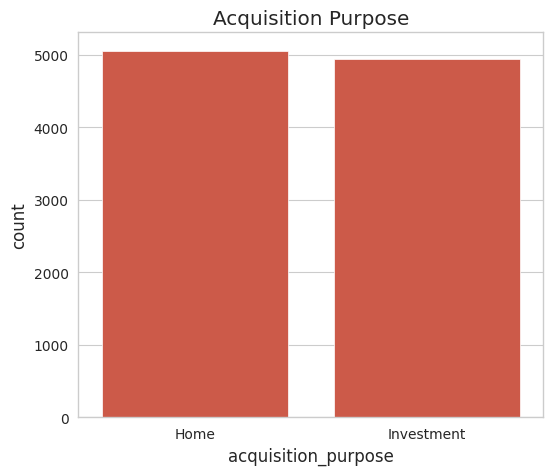

In [325]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x='acquisition_purpose'
)

plt.title("Acquisition Purpose")

plt.show()

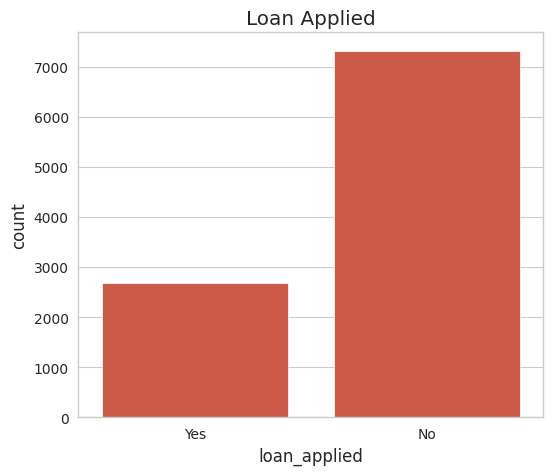

In [326]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x='loan_applied'
)

plt.title("Loan Applied")

plt.show()

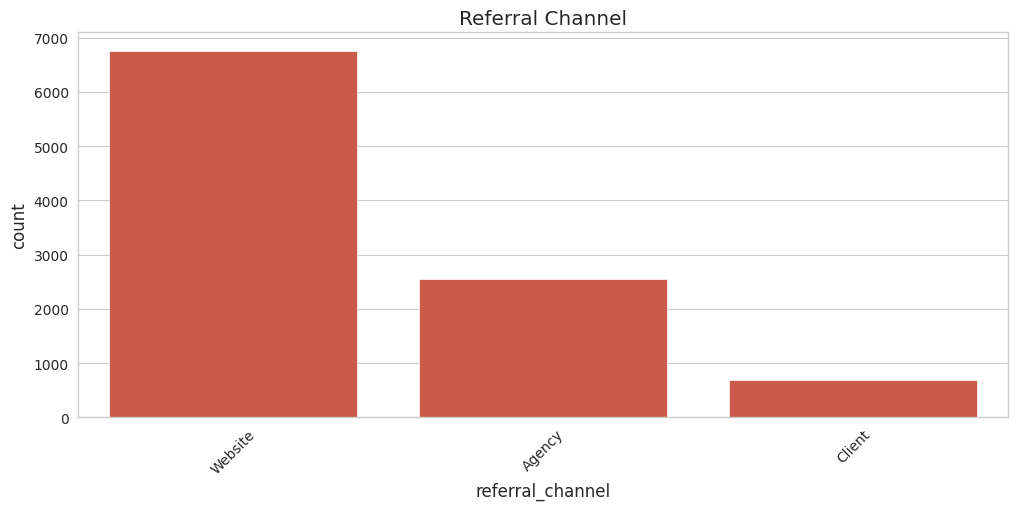

In [327]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=data,
    x='referral_channel'
)

plt.xticks(rotation=45)

plt.title("Referral Channel")

plt.show()

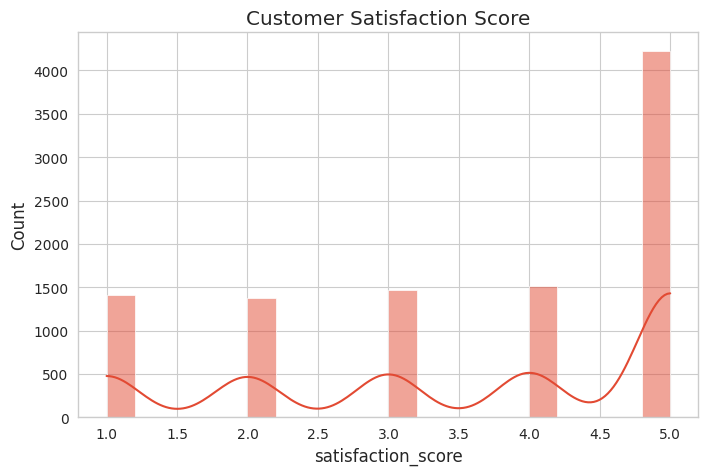

In [328]:
plt.figure(figsize=(8,5))

sns.histplot(
    data['satisfaction_score'],
    bins=20,
    kde=True
)

plt.title("Customer Satisfaction Score")

plt.show()

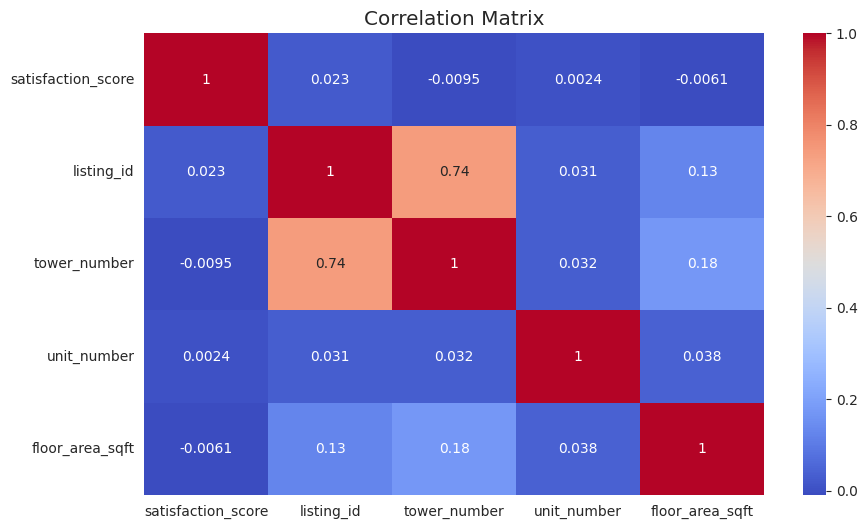

In [329]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [330]:
# Create a copy of merged dataset

df = data.copy()

print("Dataset Copied Successfully")

Dataset Copied Successfully


In [331]:
df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,"$351,419.29",Sold,C0001
1,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,"$496,266.41",Sold,C0001
2,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,"$175,599.90",Sold,C0001
3,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,"$223,479.12",Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,"$299,245.20",Sold,C0002


In [332]:
# Convert DOB to datetime

df['date_of_birth'] = pd.to_datetime(
    df['date_of_birth'],
    errors='coerce'
)

df['date_of_birth'].head()

,date_of_birth
0,1968-05-11
1,1968-05-11
2,1968-05-11
3,1968-05-11
4,NaT


In [333]:
# Current Year

current_year = datetime.now().year

# Calculate Age

df['Age'] = current_year - df['date_of_birth'].dt.year

df[['date_of_birth','Age']].head()

,date_of_birth,Age
0,1968-05-11,58.0
1,1968-05-11,58.0
2,1968-05-11,58.0
3,1968-05-11,58.0
4,NaT,NaN


In [334]:
# Remove impossible ages

df = df[(df['Age'] > 18) & (df['Age'] < 100)]

print(df.shape)

(3118, 22)


In [335]:
df.drop(columns=['date_of_birth'], inplace=True)

df.head()

,client_id,client_type,first_name,last_name,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,...,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,Age
0,C0001,Individual,Kareem,Liu,F,USA,California,Home,4,Yes,...,90343,9,10-01-2024,Apartment,40,1090.32,"$351,419.29",Sold,C0001,58.0
1,C0001,Individual,Kareem,Liu,F,USA,California,Home,4,Yes,...,4051,4,12-01-2024,Apartment,51,1608.84,"$496,266.41",Sold,C0001,58.0
2,C0001,Individual,Kareem,Liu,F,USA,California,Home,4,Yes,...,150099,15,05-01-2025,Apartment,15,522.71,"$175,599.90",Sold,C0001,58.0
3,C0001,Individual,Kareem,Liu,F,USA,California,Home,4,Yes,...,30432,3,12-01-2025,Apartment,50,713.67,"$223,479.12",Sold,C0001,58.0
9,C0003,Individual,Kale,Gay,M,USA,California,Home,4,Yes,...,10104,1,07-01-2024,Apartment,13,719.47,"$216,874.97",Sold,C0003,67.0


In [336]:
df.dtypes

,0
client_id,object
client_type,object
first_name,object
last_name,object
gender,object
country,object
region,object
acquisition_purpose,object
satisfaction_score,int64
loan_applied,object


In [337]:
numeric_columns = df.select_dtypes(include=np.number).columns

print(numeric_columns)

Index(['satisfaction_score', 'listing_id', 'tower_number', 'unit_number',
       'floor_area_sqft', 'Age'],
      dtype='object')


In [338]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['client_id', 'client_type', 'first_name', 'last_name', 'gender',
       'country', 'region', 'acquisition_purpose', 'loan_applied',
       'referral_channel', 'transaction_date', 'unit_category', 'sale_price',
       'listing_status', 'client_ref'],
      dtype='object')


In [339]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_columns = []

for col in categorical_columns:

    if df[col].nunique() == 2:

        binary_columns.append(col)

        df[col] = le.fit_transform(df[col])

print(binary_columns)

['client_type', 'gender', 'acquisition_purpose', 'loan_applied', 'unit_category']


In [340]:
remaining_cat = df.select_dtypes(include='object').columns

print(remaining_cat)

Index(['client_id', 'first_name', 'last_name', 'country', 'region',
       'referral_channel', 'transaction_date', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='object')


In [341]:
df = pd.get_dummies(

    df,

    columns=remaining_cat,

    drop_first=True

)

print(df.shape)

(3118, 5292)


In [342]:
df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,client_ref_C1976,client_ref_C1977,client_ref_C1978,client_ref_C1980,client_ref_C1981,client_ref_C1982,client_ref_C1985,client_ref_C1991,client_ref_C1993,client_ref_C1995
0,1,0,0,4,1,90343,9,0,40,1090.32,...,False,False,False,False,False,False,False,False,False,False
1,1,0,0,4,1,4051,4,0,51,1608.84,...,False,False,False,False,False,False,False,False,False,False
2,1,0,0,4,1,150099,15,0,15,522.71,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,4,1,30432,3,0,50,713.67,...,False,False,False,False,False,False,False,False,False,False
9,1,1,0,4,1,10104,1,0,13,719.47,...,False,False,False,False,False,False,False,False,False,False


In [343]:
df.isnull().sum().sum()

np.int64(0)

In [344]:
# client_ids = df['client_id'] # This line causes KeyError as 'client_id' was one-hot encoded and no longer exists

# Identify and drop all client_id dummy columns
client_id_cols_to_drop = [col for col in df.columns if col.startswith('client_id_')]
df.drop(columns=client_id_cols_to_drop, inplace=True)

# Identify and drop all client_ref dummy columns (as client_ref is also an identifier)
client_ref_cols_to_drop = [col for col in df.columns if col.startswith('client_ref_')]
df.drop(columns=client_ref_cols_to_drop, inplace=True)

df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$693,830.82","sale_price_$705,388.85","sale_price_$705,490.95","sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38"
0,1,0,0,4,1,90343,9,0,40,1090.32,...,False,False,False,False,False,False,False,False,False,False
1,1,0,0,4,1,4051,4,0,51,1608.84,...,False,False,False,False,False,False,False,False,False,False
2,1,0,0,4,1,150099,15,0,15,522.71,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,4,1,30432,3,0,50,713.67,...,False,False,False,False,False,False,False,False,False,False
9,1,1,0,4,1,10104,1,0,13,719.47,...,False,False,False,False,False,False,False,False,False,False


In [345]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [346]:
scaled_df = pd.DataFrame(

    scaled_data,

    columns=df.columns

)

scaled_df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$693,830.82","sale_price_$705,388.85","sale_price_$705,490.95","sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38"
0,0.215195,-0.992969,-0.677536,0.687373,1.28945,-0.219010,-0.233780,-0.423407,0.648484,-0.132113,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
1,0.215195,-0.992969,-0.677536,0.687373,1.28945,-1.689819,-1.098460,-0.423407,1.296780,1.086587,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
2,0.215195,-0.992969,-0.677536,0.687373,1.28945,0.799504,0.803836,-0.423407,-0.824914,-1.466192,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
3,0.215195,-0.992969,-0.677536,0.687373,1.28945,-1.240167,-1.271396,-0.423407,1.237844,-1.017370,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
4,0.215195,1.007081,-0.677536,0.687373,1.28945,-1.586649,-1.617268,-0.423407,-0.942786,-1.003738,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911


In [347]:
scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
client_type,3118.0,2.278841e-16,1.00016,-4.646956,0.215195,0.215195,0.215195,0.215195
gender,3118.0,-6.836524e-18,1.00016,-0.992969,-0.992969,-0.992969,1.007081,1.007081
acquisition_purpose,3118.0,5.241335e-17,1.00016,-0.677536,-0.677536,-0.677536,1.475937,1.475937
satisfaction_score,3118.0,-1.150815e-16,1.00016,-1.468793,-0.750071,-0.031349,0.687373,1.406095
loan_applied,3118.0,1.367305e-17,1.00016,-0.775524,-0.775524,-0.775524,1.289450,1.289450
...,...,...,...,...,...,...,...,...
"sale_price_$724,345.49",3118.0,6.836524e-18,1.00016,-0.017911,-0.017911,-0.017911,-0.017911,55.830099
"sale_price_$726,903.51",3118.0,7.975945e-18,1.00016,-0.017911,-0.017911,-0.017911,-0.017911,55.830099
"sale_price_$728,976.07",3118.0,6.836524e-18,1.00016,-0.017911,-0.017911,-0.017911,-0.017911,55.830099
"sale_price_$734,390.86",3118.0,6.836524e-18,1.00016,-0.017911,-0.017911,-0.017911,-0.017911,55.830099


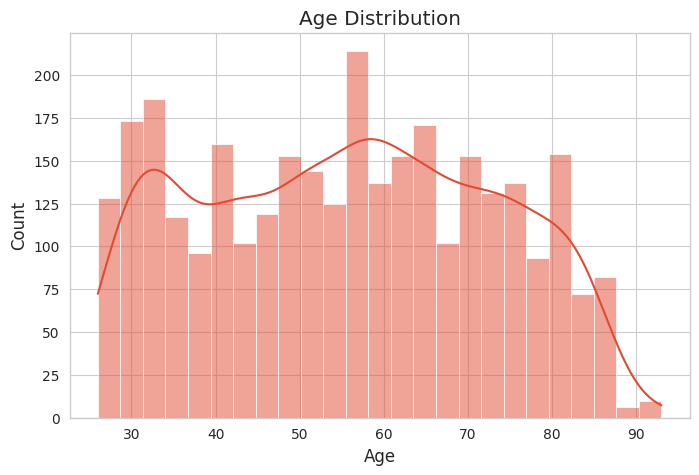

In [348]:
plt.figure(figsize=(8,5))

sns.histplot(

    df['Age'],

    bins=25,

    kde=True

)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.show()

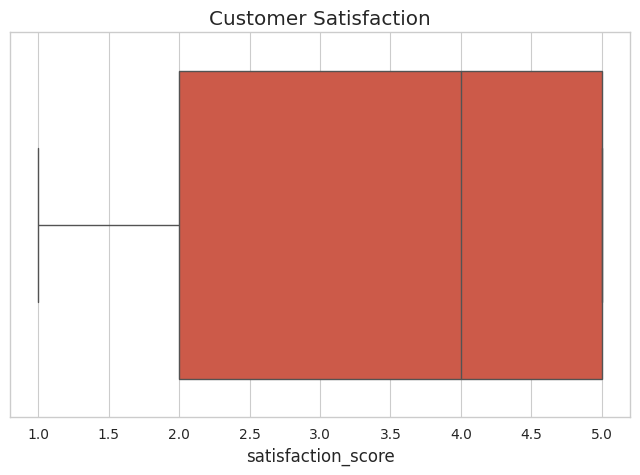

In [349]:
plt.figure(figsize=(8,5))

sns.boxplot(

    x=data['satisfaction_score']

)

plt.title("Customer Satisfaction")

plt.show()

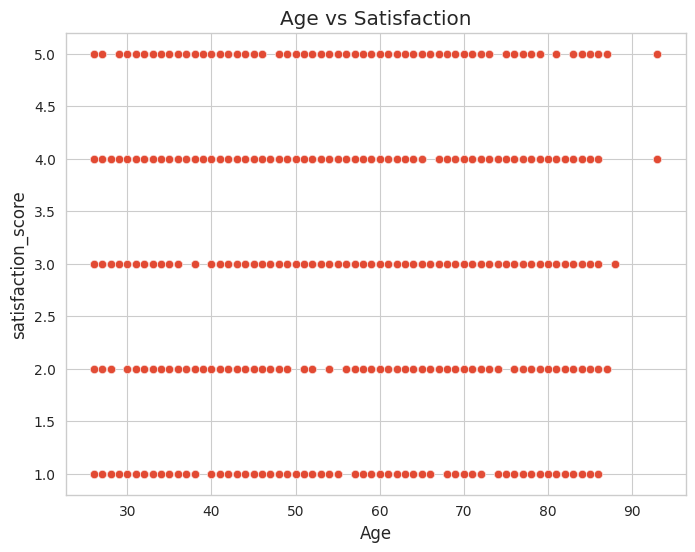

In [350]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=df, # Changed data to df

    x='Age',

    y='satisfaction_score',

    alpha=0.7

)

plt.title("Age vs Satisfaction")

plt.show()

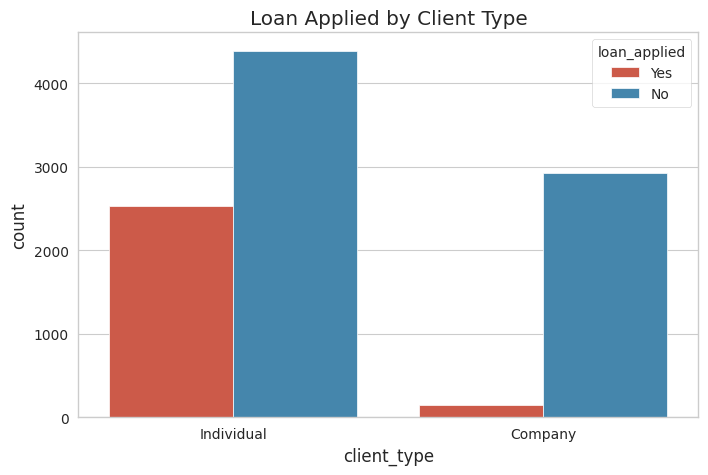

In [351]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=data,

    x='client_type',

    hue='loan_applied'

)

plt.title("Loan Applied by Client Type")

plt.show()

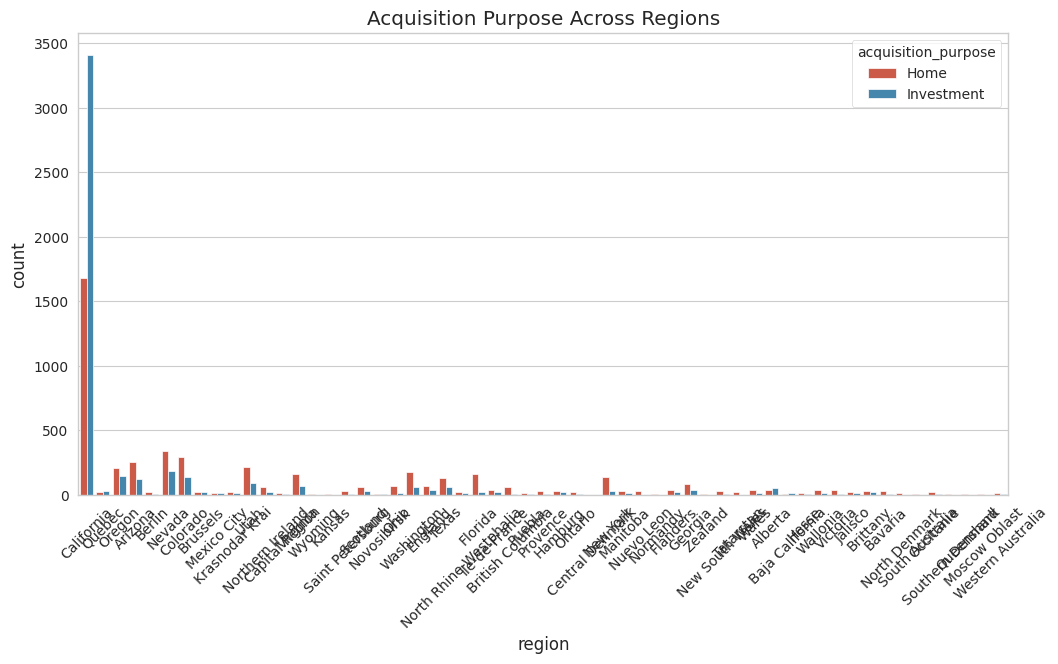

In [352]:
plt.figure(figsize=(12,6))

sns.countplot(

    data=data,

    x='region',

    hue='acquisition_purpose'

)

plt.xticks(rotation=45)

plt.title("Acquisition Purpose Across Regions")

plt.show()

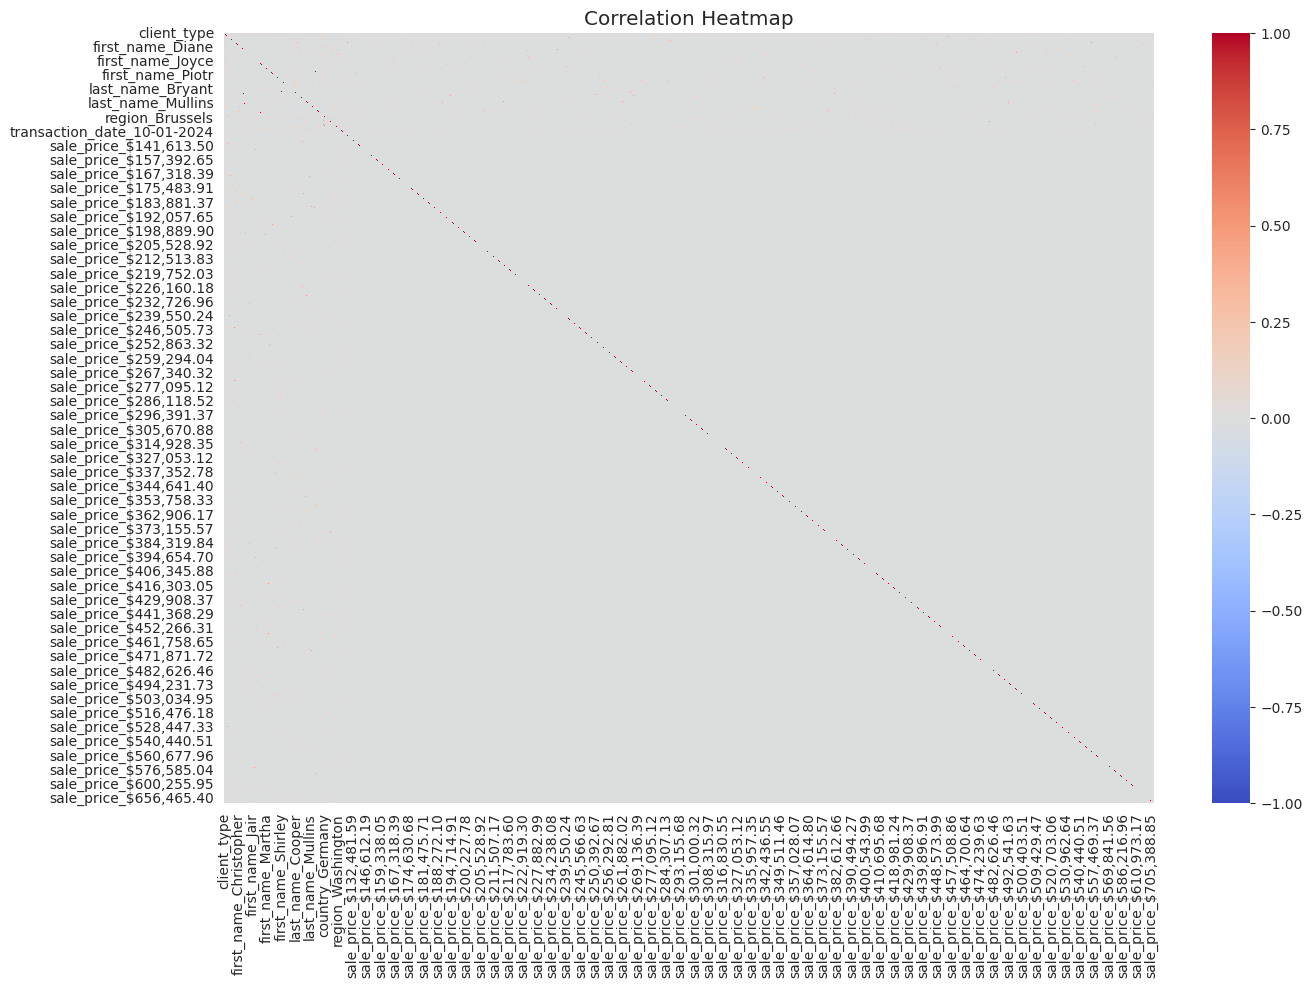

In [353]:
plt.figure(figsize=(15,10))

sns.heatmap(

    scaled_df.corr(),

    cmap='coolwarm',

    center=0

)

plt.title("Correlation Heatmap")

plt.show()

In [354]:
print("Final Shape :", scaled_df.shape)

scaled_df.head()

Final Shape : (3118, 3584)


,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$693,830.82","sale_price_$705,388.85","sale_price_$705,490.95","sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38"
0,0.215195,-0.992969,-0.677536,0.687373,1.28945,-0.219010,-0.233780,-0.423407,0.648484,-0.132113,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
1,0.215195,-0.992969,-0.677536,0.687373,1.28945,-1.689819,-1.098460,-0.423407,1.296780,1.086587,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
2,0.215195,-0.992969,-0.677536,0.687373,1.28945,0.799504,0.803836,-0.423407,-0.824914,-1.466192,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
3,0.215195,-0.992969,-0.677536,0.687373,1.28945,-1.240167,-1.271396,-0.423407,1.237844,-1.017370,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
4,0.215195,1.007081,-0.677536,0.687373,1.28945,-1.586649,-1.617268,-0.423407,-0.942786,-1.003738,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911


In [355]:
scaled_df.to_csv(

    "processed_buyer_data.csv",

    index=False

)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [356]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [357]:
scaled_df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$693,830.82","sale_price_$705,388.85","sale_price_$705,490.95","sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38"
0,0.215195,-0.992969,-0.677536,0.687373,1.28945,-0.219010,-0.233780,-0.423407,0.648484,-0.132113,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
1,0.215195,-0.992969,-0.677536,0.687373,1.28945,-1.689819,-1.098460,-0.423407,1.296780,1.086587,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
2,0.215195,-0.992969,-0.677536,0.687373,1.28945,0.799504,0.803836,-0.423407,-0.824914,-1.466192,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
3,0.215195,-0.992969,-0.677536,0.687373,1.28945,-1.240167,-1.271396,-0.423407,1.237844,-1.017370,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
4,0.215195,1.007081,-0.677536,0.687373,1.28945,-1.586649,-1.617268,-0.423407,-0.942786,-1.003738,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911


In [358]:
wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_df)

    wcss.append(model.inertia_)

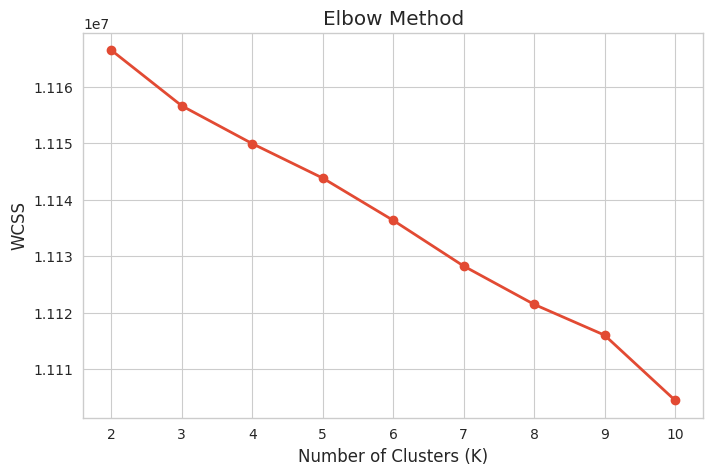

In [359]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [360]:
silhouette_scores = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_df)

    score = silhouette_score(
        scaled_df,
        labels
    )

    silhouette_scores.append(score)

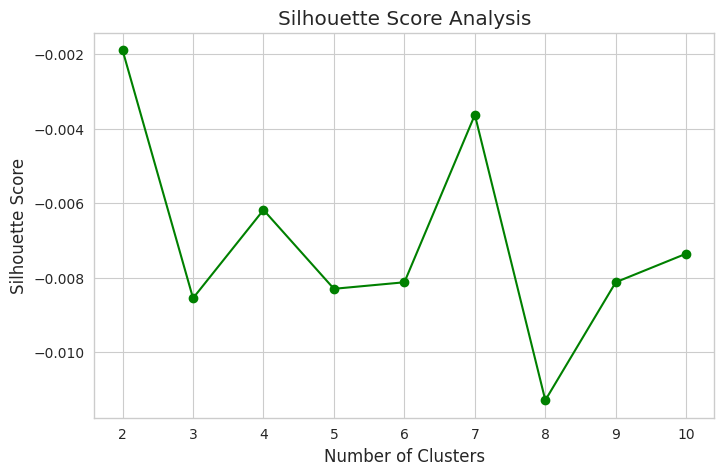

In [361]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o',
    color='green'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score Analysis")

plt.grid(True)

plt.show()

In [362]:
for k,score in zip(range(2,11), silhouette_scores):

    print(f"K = {k}  -->  Silhouette Score = {score:.4f}")

K = 2  -->  Silhouette Score = -0.0019
K = 3  -->  Silhouette Score = -0.0085
K = 4  -->  Silhouette Score = -0.0062
K = 5  -->  Silhouette Score = -0.0083
K = 6  -->  Silhouette Score = -0.0081
K = 7  -->  Silhouette Score = -0.0036
K = 8  -->  Silhouette Score = -0.0113
K = 9  -->  Silhouette Score = -0.0081
K = 10  -->  Silhouette Score = -0.0074


In [363]:
optimal_clusters = 4

In [364]:
kmeans = KMeans(

    n_clusters=optimal_clusters,

    random_state=42,

    n_init=10

)

clusters = kmeans.fit_predict(scaled_df)

In [365]:
df['Cluster'] = clusters

df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$705,388.85","sale_price_$705,490.95","sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38",Cluster
0,1,0,0,4,1,90343,9,0,40,1090.32,...,False,False,False,False,False,False,False,False,False,2
1,1,0,0,4,1,4051,4,0,51,1608.84,...,False,False,False,False,False,False,False,False,False,2
2,1,0,0,4,1,150099,15,0,15,522.71,...,False,False,False,False,False,False,False,False,False,2
3,1,0,0,4,1,30432,3,0,50,713.67,...,False,False,False,False,False,False,False,False,False,2
9,1,1,0,4,1,10104,1,0,13,719.47,...,False,False,False,False,False,False,False,False,False,2


In [366]:
cluster_count = df['Cluster'].value_counts().sort_index()

print(cluster_count)

Cluster
0      29
1      42
2    3043
3       4
Name: count, dtype: int64


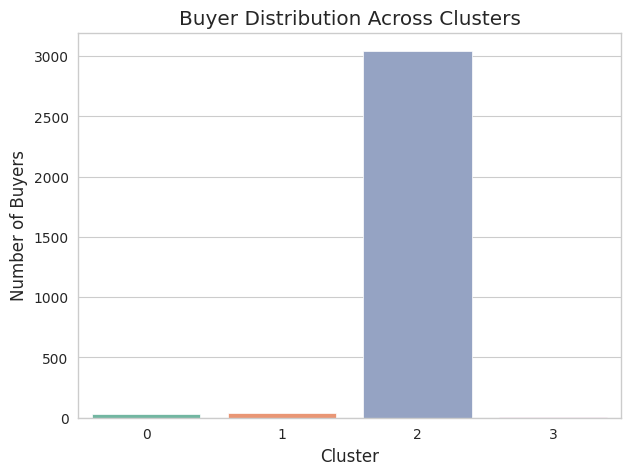

In [367]:
plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x='Cluster',

    palette='Set2'

)

plt.title("Buyer Distribution Across Clusters")

plt.xlabel("Cluster")

plt.ylabel("Number of Buyers")

plt.show()

In [368]:
centers = pd.DataFrame(

    kmeans.cluster_centers_,

    columns=scaled_df.columns

)

centers

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$693,830.82","sale_price_$705,388.85","sale_price_$705,490.95","sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38"
0,0.215195,0.248441,0.065041,0.117352,0.292566,0.132122,0.124019,-0.135283,0.048964,-0.136909,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
1,0.215195,0.483258,-0.164804,0.037101,0.207797,0.055533,0.046212,-0.091836,0.070351,0.051056,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911
2,-0.005304,-0.010361,-0.000285,-0.001589,-0.004637,-0.001578,-0.001456,0.002198,-0.001089,0.001342,...,0.000441,0.000441,0.000441,0.000441,0.000441,0.000441,0.000441,0.000441,0.000441,0.000441
3,0.215195,1.007081,1.475937,-0.031349,-0.775524,-0.340726,-0.277014,0.272892,-0.265023,-0.564189,...,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911,-0.017911


In [369]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$693,830.82","sale_price_$705,388.85","sale_price_$705,490.95","sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38"
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.00000,0.620690,0.344828,3.206897,0.517241,110943.827586,11.068966,0.103448,29.827586,1088.279655,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.00000,0.738095,0.238095,3.095238,0.476190,106450.380952,10.619048,0.119048,30.190476,1168.253095,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.95465,0.491291,0.314492,3.041407,0.373316,103099.726257,10.343411,0.152810,28.978311,1147.100976,...,0.000329,0.000329,0.000329,0.000329,0.000329,0.000329,0.000329,0.000329,0.000329,0.000329
3,1.00000,1.000000,1.000000,3.000000,0.000000,83202.000000,8.750000,0.250000,24.500000,906.485000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [370]:
pd.crosstab(

    df['Cluster'],

    df['client_type']

)

client_type,0,1
Cluster,,
0,0,29
1,0,42
2,138,2905
3,0,4


In [371]:
pd.crosstab(

    df['Cluster'],

    df['acquisition_purpose']

)

acquisition_purpose,0,1
Cluster,,
0,19,10
1,32,10
2,2086,957
3,0,4


In [372]:
pd.crosstab(

    df['Cluster'],

    df['loan_applied']

)

loan_applied,0,1
Cluster,,
0,14,15
1,22,20
2,1907,1136
3,4,0


In [373]:
pd.crosstab(

    df['Cluster'],

    df['gender']

)

gender,0,1
Cluster,,
0,11,18
1,11,31
2,1548,1495
3,0,4


In [374]:
pd.crosstab(

    df['Cluster'],

    data.loc[df.index, 'region']

)

region,Alberta,Arizona,Baja California,Bavaria,Berlin,British Columbia,Brittany,Brussels,California,Capital Region,...,Tatarstan,Texas,Utah,Victoria,Virginia,Wales,Wallonia,Washington,Western Australia,Zealand
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,9,0,...,0,0,4,0,0,0,0,3,0,0
2,41,139,10,17,16,37,29,27,991,8,...,7,80,157,28,79,22,22,77,6,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [375]:
pd.crosstab(

    df['Cluster'],

    data.loc[df.index, 'country']

)

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
Cluster,,,,,,,,,,
0,0,0,0,0,0,0,18,5,0,6
1,0,0,3,0,0,0,4,0,0,35
2,62,64,150,27,74,81,41,48,166,2330
3,0,0,0,0,0,0,0,4,0,0


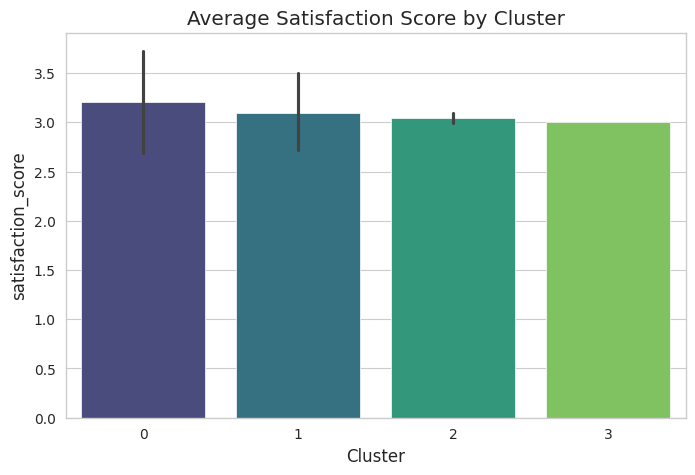

In [376]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=df,

    x='Cluster',

    y='satisfaction_score',

    palette='viridis'

)

plt.title("Average Satisfaction Score by Cluster")

plt.show()

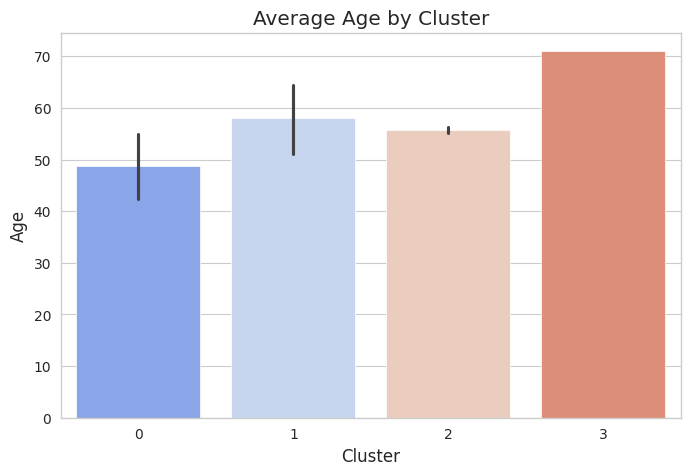

In [377]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=df,

    x='Cluster',

    y='Age',

    palette='coolwarm'

)

plt.title("Average Age by Cluster")

plt.show()

In [378]:
cluster_profile = df.groupby("Cluster").agg({

    "Age":"mean",

    "satisfaction_score":"mean",

    "Cluster":"size" # Use 'size' to count the number of rows (buyers) in each cluster

}).rename(columns={

    "Cluster":"Number_of_Buyers"

})

cluster_profile

,Age,satisfaction_score,Number_of_Buyers
Cluster,,,
0,48.689655,3.206897,29
1,57.976190,3.095238,42
2,55.651988,3.041407,3043
3,71.000000,3.000000,4


In [379]:
cluster_names = {

    0:"Global Investors",

    1:"First-Time Buyers",

    2:"Corporate Buyers",

    3:"Luxury Investors"

}

df["Buyer_Segment"] = df["Cluster"].map(cluster_names)

df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$705,490.95","sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38",Cluster,Buyer_Segment
0,1,0,0,4,1,90343,9,0,40,1090.32,...,False,False,False,False,False,False,False,False,2,Corporate Buyers
1,1,0,0,4,1,4051,4,0,51,1608.84,...,False,False,False,False,False,False,False,False,2,Corporate Buyers
2,1,0,0,4,1,150099,15,0,15,522.71,...,False,False,False,False,False,False,False,False,2,Corporate Buyers
3,1,0,0,4,1,30432,3,0,50,713.67,...,False,False,False,False,False,False,False,False,2,Corporate Buyers
9,1,1,0,4,1,10104,1,0,13,719.47,...,False,False,False,False,False,False,False,False,2,Corporate Buyers


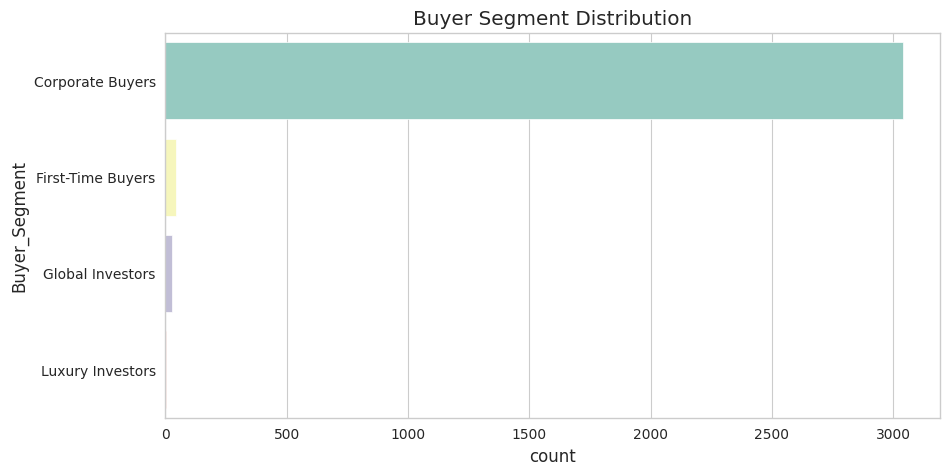

In [380]:
plt.figure(figsize=(10,5))

sns.countplot(

    data=df,

    y="Buyer_Segment",

    palette="Set3",

    order=df["Buyer_Segment"].value_counts().index

)

plt.title("Buyer Segment Distribution")

plt.show()

In [381]:
data.to_csv(

    "Buyer_Segmentation_Output.csv",

    index=False

)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


In [382]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

In [383]:
# Ward Linkage

linkage_matrix = linkage(
    scaled_df,
    method='ward'
)

print("Linkage Matrix Created Successfully")

Linkage Matrix Created Successfully


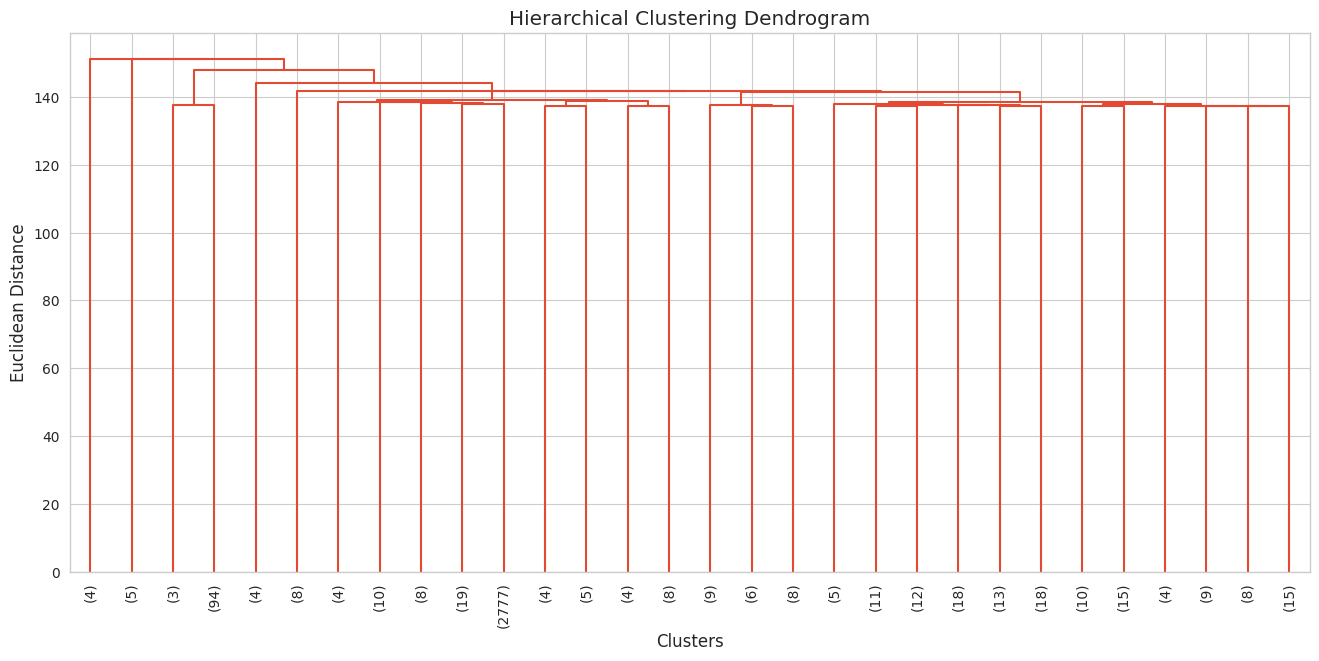

In [384]:
plt.figure(figsize=(16,7))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Clusters")

plt.ylabel("Euclidean Distance")

plt.show()

In [385]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

hier_clusters = hierarchical.fit_predict(scaled_df)

In [386]:
df["Hierarchical_Cluster"] = hier_clusters

df.head()

,client_type,gender,acquisition_purpose,satisfaction_score,loan_applied,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,...,"sale_price_$720,425.67","sale_price_$720,719.85","sale_price_$724,345.49","sale_price_$726,903.51","sale_price_$728,976.07","sale_price_$734,390.86","sale_price_$734,629.38",Cluster,Buyer_Segment,Hierarchical_Cluster
0,1,0,0,4,1,90343,9,0,40,1090.32,...,False,False,False,False,False,False,False,2,Corporate Buyers,0
1,1,0,0,4,1,4051,4,0,51,1608.84,...,False,False,False,False,False,False,False,2,Corporate Buyers,0
2,1,0,0,4,1,150099,15,0,15,522.71,...,False,False,False,False,False,False,False,2,Corporate Buyers,0
3,1,0,0,4,1,30432,3,0,50,713.67,...,False,False,False,False,False,False,False,2,Corporate Buyers,0
9,1,1,0,4,1,10104,1,0,13,719.47,...,False,False,False,False,False,False,False,2,Corporate Buyers,0


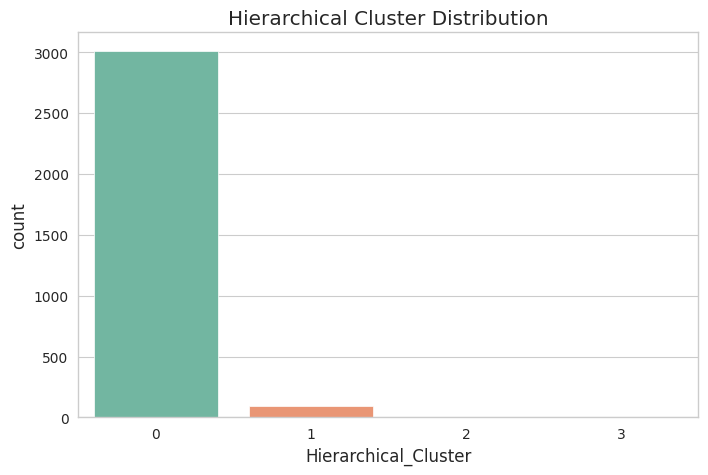

In [387]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Hierarchical_Cluster",
    palette="Set2"
)

plt.title("Hierarchical Cluster Distribution")

plt.show()

In [388]:
comparison = pd.crosstab(
    df["Cluster"],
    df["Hierarchical_Cluster"]
)

comparison

Hierarchical_Cluster,0,1,2,3
Cluster,,,,
0,29,0,0,0
1,42,0,0,0
2,2937,97,5,4
3,4,0,0,0


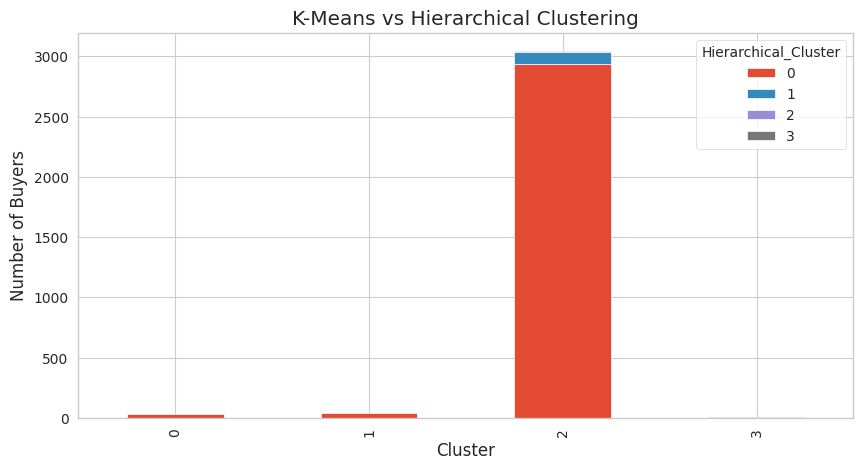

In [389]:
comparison = pd.crosstab(
    df["Cluster"],
    df["Hierarchical_Cluster"]
)

fig, ax = plt.subplots(figsize=(10,5))

comparison.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

plt.title("K-Means vs Hierarchical Clustering")

plt.ylabel("Number of Buyers")

plt.show()

In [390]:
df.groupby(
    "Hierarchical_Cluster"
)["Age"].mean()

,Age
Hierarchical_Cluster,
0,55.886786
1,47.422680
2,61.000000
3,61.000000


In [391]:
df.groupby(
    "Hierarchical_Cluster"
)["satisfaction_score"].mean()

,satisfaction_score
Hierarchical_Cluster,
0,3.051793
1,2.876289
2,3.000000
3,1.000000


In [392]:
pd.crosstab(
    df["Hierarchical_Cluster"],
    df["client_type"]
)

client_type,0,1
Hierarchical_Cluster,,
0,41,2971
1,97,0
2,0,5
3,0,4


In [393]:
pd.crosstab(
    df["Hierarchical_Cluster"],
    df["loan_applied"]
)

loan_applied,0,1
Hierarchical_Cluster,,
0,1878,1134
1,60,37
2,5,0
3,4,0


In [394]:
pd.crosstab(
    df["Hierarchical_Cluster"],
    df["acquisition_purpose"]
)

acquisition_purpose,0,1
Hierarchical_Cluster,,
0,2064,948
1,68,29
2,5,0
3,0,4


In [395]:
pd.crosstab(
    df["Hierarchical_Cluster"],
    data.loc[df.index, "country"]
)

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
Hierarchical_Cluster,,,,,,,,,,
0,59,64,150,23,74,81,58,54,166,2283
1,3,0,3,0,0,0,0,3,0,88
2,0,0,0,0,0,0,5,0,0,0
3,0,0,0,4,0,0,0,0,0,0


In [396]:
pd.crosstab(
    df["Hierarchical_Cluster"],
    data.loc[df.index, "region"]
)

region,Alberta,Arizona,Baja California,Bavaria,Berlin,British Columbia,Brittany,Brussels,California,Capital Region,...,Tatarstan,Texas,Utah,Victoria,Virginia,Wales,Wallonia,Washington,Western Australia,Zealand
Hierarchical_Cluster,,,,,,,,,,,,,,,,,,,,,
0,38,132,10,17,16,37,29,27,971,4,...,7,73,161,28,72,22,22,80,6,4
1,3,7,0,0,0,0,0,0,33,0,...,0,7,0,0,7,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


In [397]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_df)

In [398]:
pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2"]
)

# Assign the 'Cluster' values from df to pca_df, ensuring positional alignment
pca_df["Cluster"] = df["Cluster"].reset_index(drop=True)

pca_df.head()

,PC1,PC2,Cluster
0,1.827925,-1.067232,2
1,2.019857,-0.925141,2
2,1.873063,-0.767127,2
3,1.920712,-0.804550,2
4,3.364981,1.016351,2


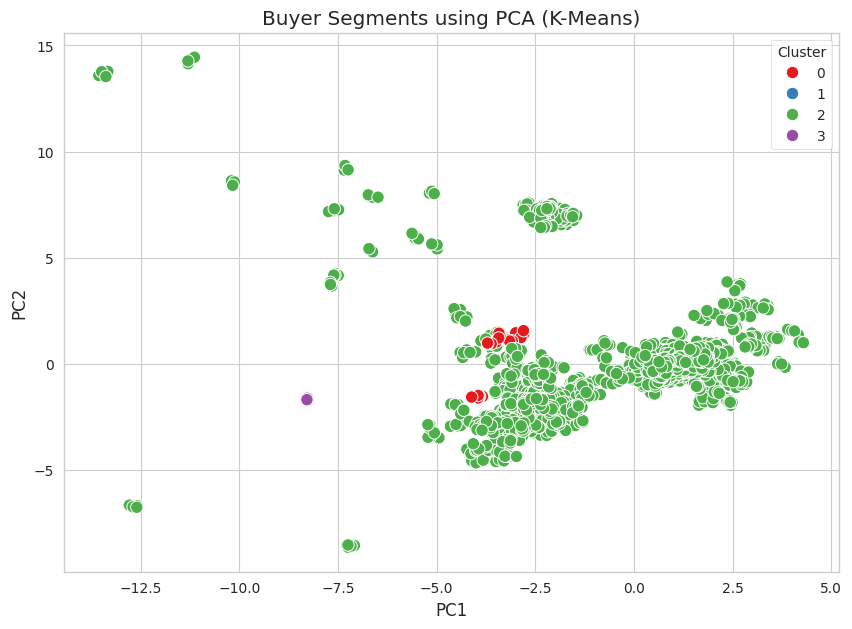

In [399]:
pca_df['Cluster'] = pca_df['Cluster'].astype('category')

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Buyer Segments using PCA (K-Means)")

plt.show()

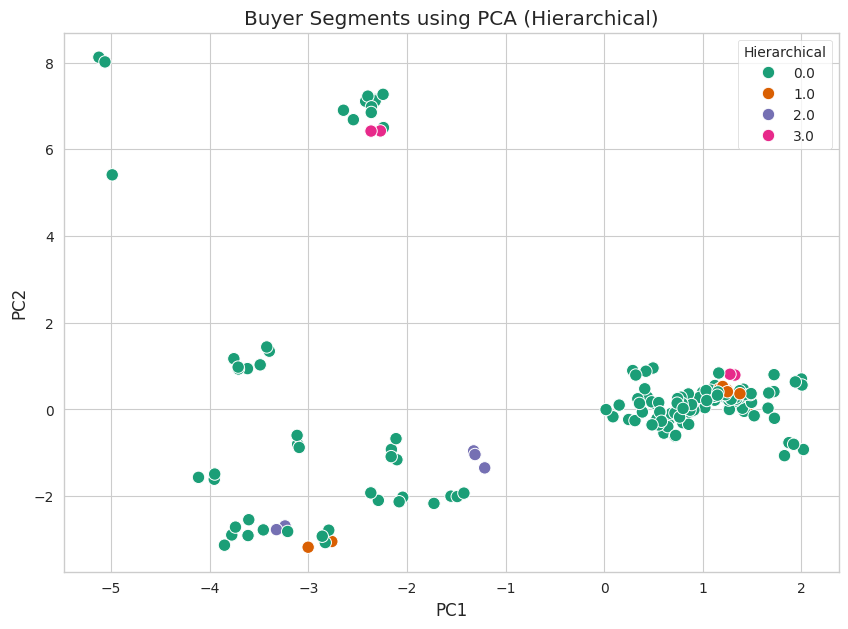

In [400]:
pca_df["Hierarchical"] = df["Hierarchical_Cluster"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Hierarchical",
    palette="Dark2",
    s=80
)

plt.title("Buyer Segments using PCA (Hierarchical)")

plt.show()

In [401]:
variance = pca.explained_variance_ratio_

print("PC1 :", round(variance[0]*100,2), "%")

print("PC2 :", round(variance[1]*100,2), "%")

print("Total Explained Variance :", round(sum(variance)*100,2), "%")

PC1 : 0.12 %
PC2 : 0.12 %
Total Explained Variance : 0.24 %


In [402]:
pca_df.to_csv(
    "buyer_segments_pca.csv",
    index=False
)

print("PCA dataset saved successfully.")

PCA dataset saved successfully.


In [403]:
df.to_csv(
    "Buyer_Segmentation_Final.csv",
    index=False
)

print("Final dataset saved successfully.")

Final dataset saved successfully.


In [404]:
for cluster in sorted(df["Cluster"].unique()):

    print("="*60)

    print(f"Buyer Segment {cluster}")

    print("="*60)

    print("Average Age :",
          round(df[df["Cluster"]==cluster]["Age"].mean(),1))

    print("Average Satisfaction :",
          round(df[df["Cluster"]==cluster]["satisfaction_score"].mean(),2))

    print("Top Client Type")

    print(df[df["Cluster"]==cluster]["client_type"].mode()[0])

    print("Top Acquisition Purpose")

    print(df[df["Cluster"]==cluster]["acquisition_purpose"].mode()[0])

    print()

Buyer Segment 0
Average Age : 48.7
Average Satisfaction : 3.21
Top Client Type
1
Top Acquisition Purpose
0

Buyer Segment 1
Average Age : 58.0
Average Satisfaction : 3.1
Top Client Type
1
Top Acquisition Purpose
0

Buyer Segment 2
Average Age : 55.7
Average Satisfaction : 3.04
Top Client Type
1
Top Acquisition Purpose
0

Buyer Segment 3
Average Age : 71.0
Average Satisfaction : 3.0
Top Client Type
1
Top Acquisition Purpose
1



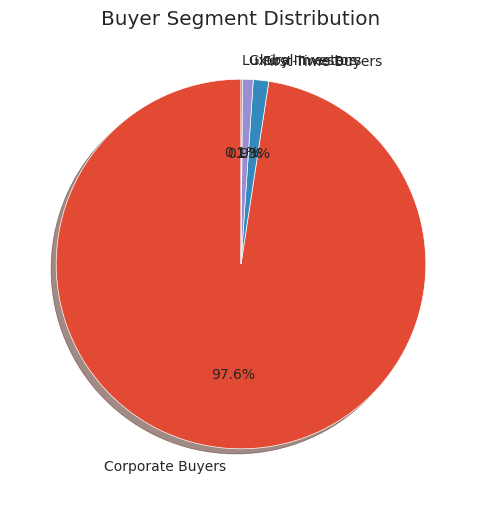

In [405]:
plt.figure(figsize=(10,6))

segment_counts = df["Buyer_Segment"].value_counts()

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

plt.title("Buyer Segment Distribution")

plt.show()

In [406]:
segment_summary = df.groupby("Buyer_Segment").agg({

    "Buyer_Segment":"size",

    "Age":"mean",

    "satisfaction_score":"mean"

})

segment_summary.rename(columns={

    "Buyer_Segment":"Total Buyers",

    "Age":"Average Age",

    "satisfaction_score":"Average Satisfaction"

}, inplace=True)

segment_summary

,Total Buyers,Average Age,Average Satisfaction
Buyer_Segment,,,
Corporate Buyers,3043,55.651988,3.041407
First-Time Buyers,42,57.976190,3.095238
Global Investors,29,48.689655,3.206897
Luxury Investors,4,71.000000,3.000000


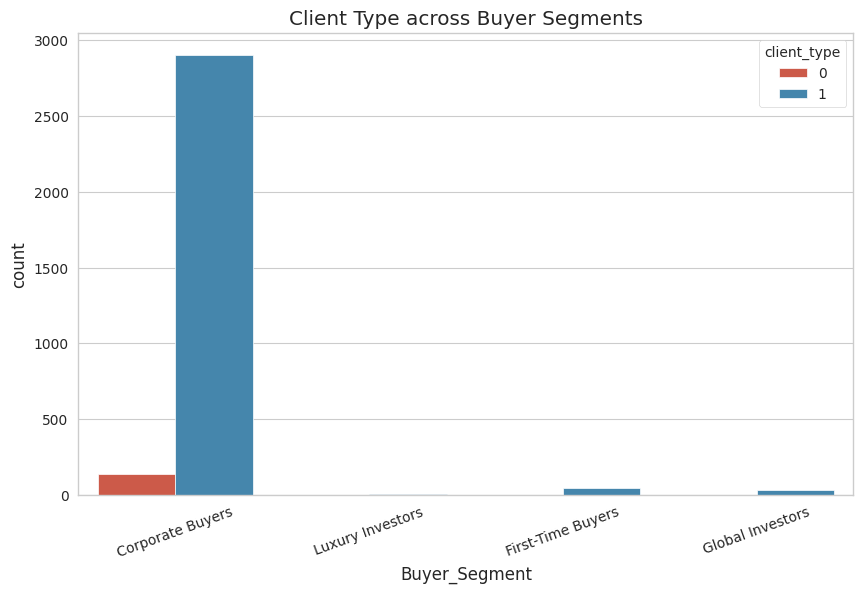

In [407]:
plt.figure(figsize=(10,6))

sns.countplot(

    data=df,

    x="Buyer_Segment",

    hue="client_type"

)

plt.xticks(rotation=20)

plt.title("Client Type across Buyer Segments")

plt.show()

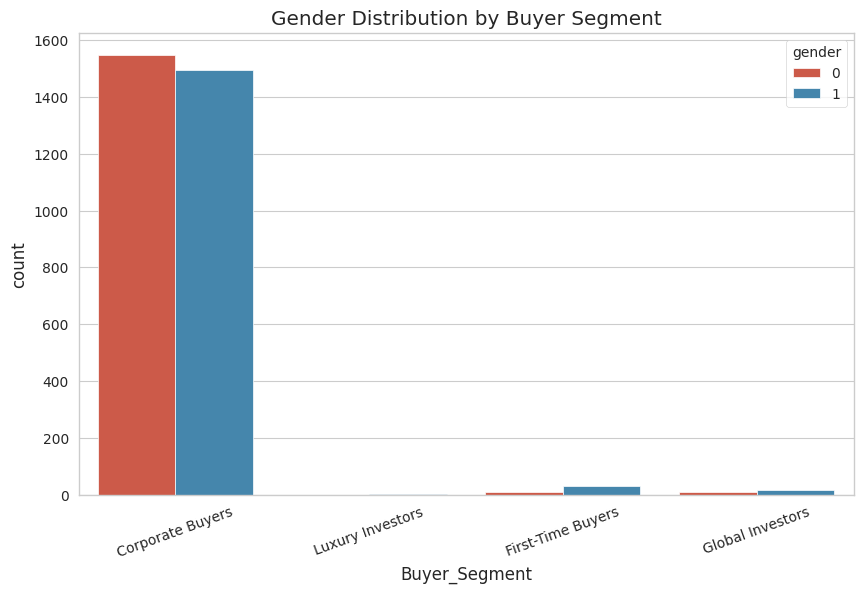

In [408]:
plt.figure(figsize=(10,6))

sns.countplot(

    data=df,

    x="Buyer_Segment",

    hue="gender"

)

plt.xticks(rotation=20)

plt.title("Gender Distribution by Buyer Segment")

plt.show()

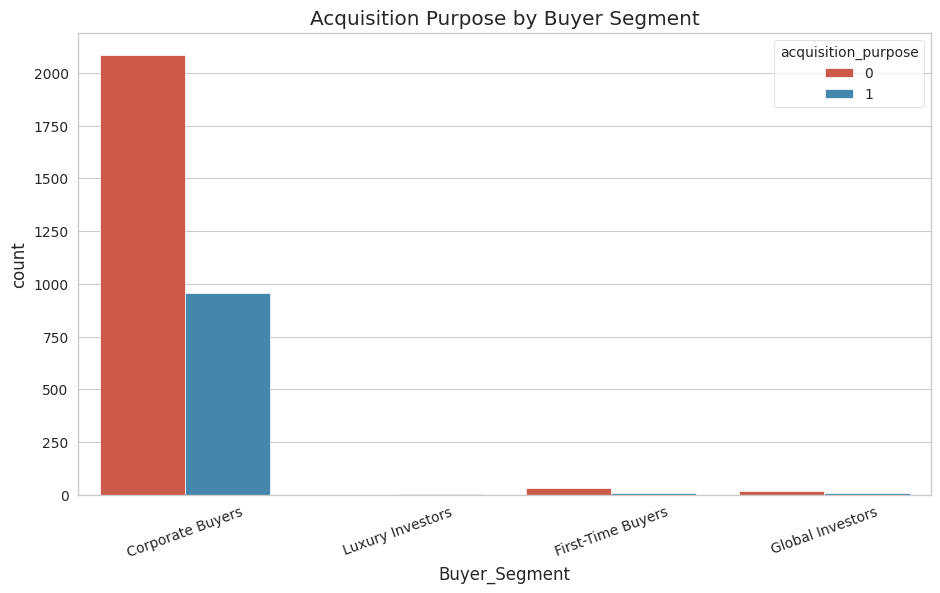

In [409]:
plt.figure(figsize=(11,6))

sns.countplot(

    data=df,

    x="Buyer_Segment",

    hue="acquisition_purpose"

)

plt.xticks(rotation=20)

plt.title("Acquisition Purpose by Buyer Segment")

plt.show()

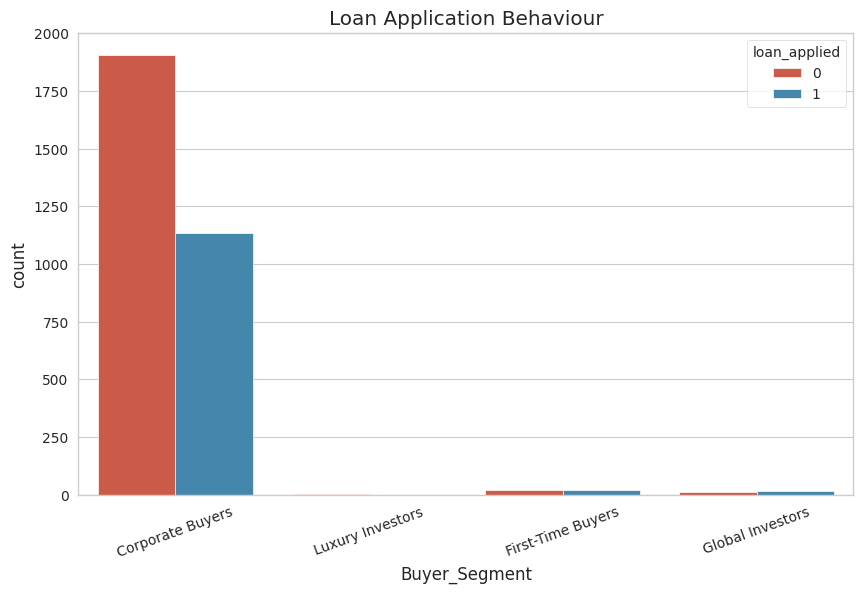

In [410]:
plt.figure(figsize=(10,6))

sns.countplot(

    data=df,

    x="Buyer_Segment",

    hue="loan_applied"

)

plt.xticks(rotation=20)

plt.title("Loan Application Behaviour")

plt.show()

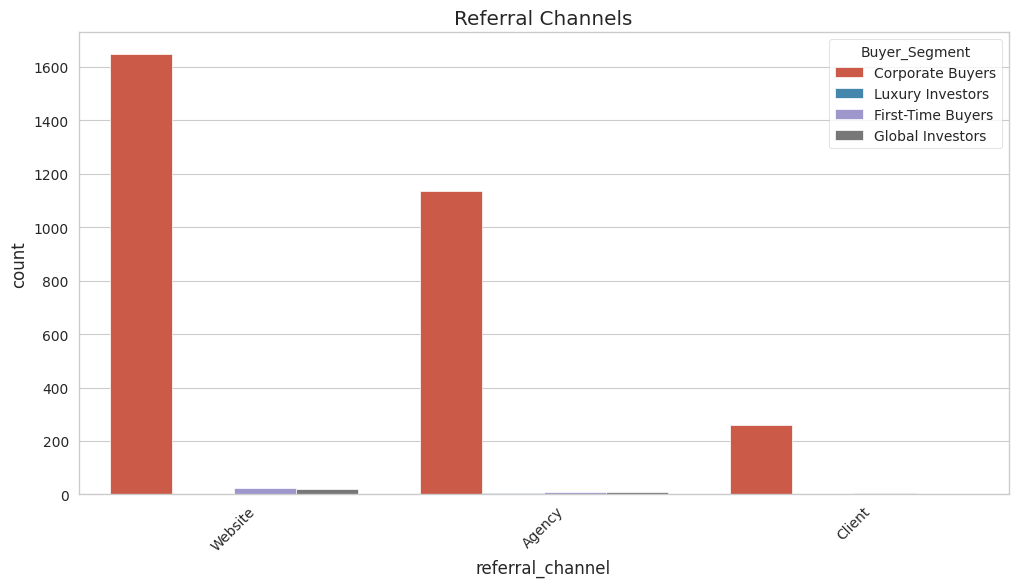

In [411]:
plot_data_temp = pd.DataFrame({
    'referral_channel': data.loc[df.index, 'referral_channel'],
    'Buyer_Segment': df['Buyer_Segment']
})

plt.figure(figsize=(12,6))
sns.countplot(
    data=plot_data_temp,
    x="referral_channel",
    hue="Buyer_Segment"
)
plt.xticks(rotation=45)
plt.title("Referral Channels")
plt.show()

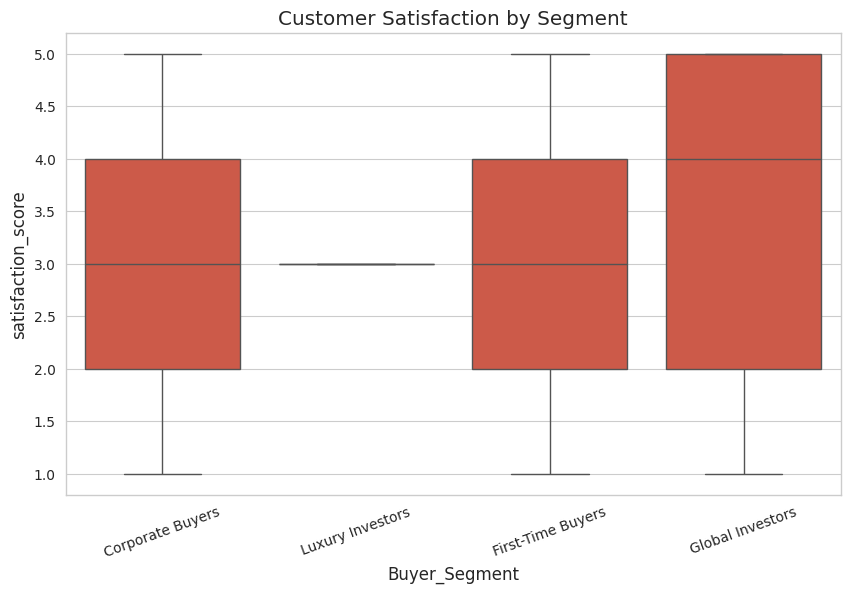

In [412]:
plt.figure(figsize=(10,6))

sns.boxplot(

    data=df,

    x="Buyer_Segment",

    y="satisfaction_score"

)

plt.xticks(rotation=20)

plt.title("Customer Satisfaction by Segment")

plt.show()

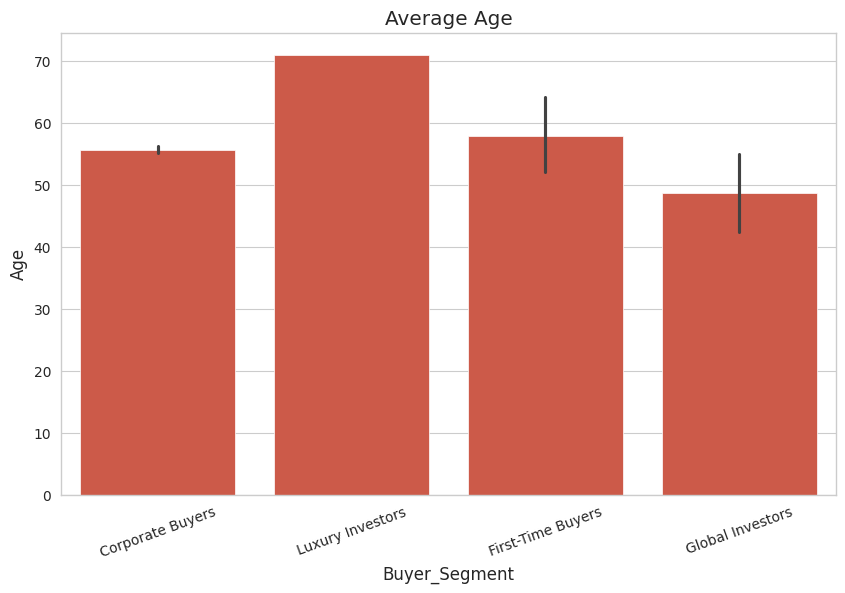

In [413]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=df,

    x="Buyer_Segment",

    y="Age"

)

plt.xticks(rotation=20)

plt.title("Average Age")

plt.show()

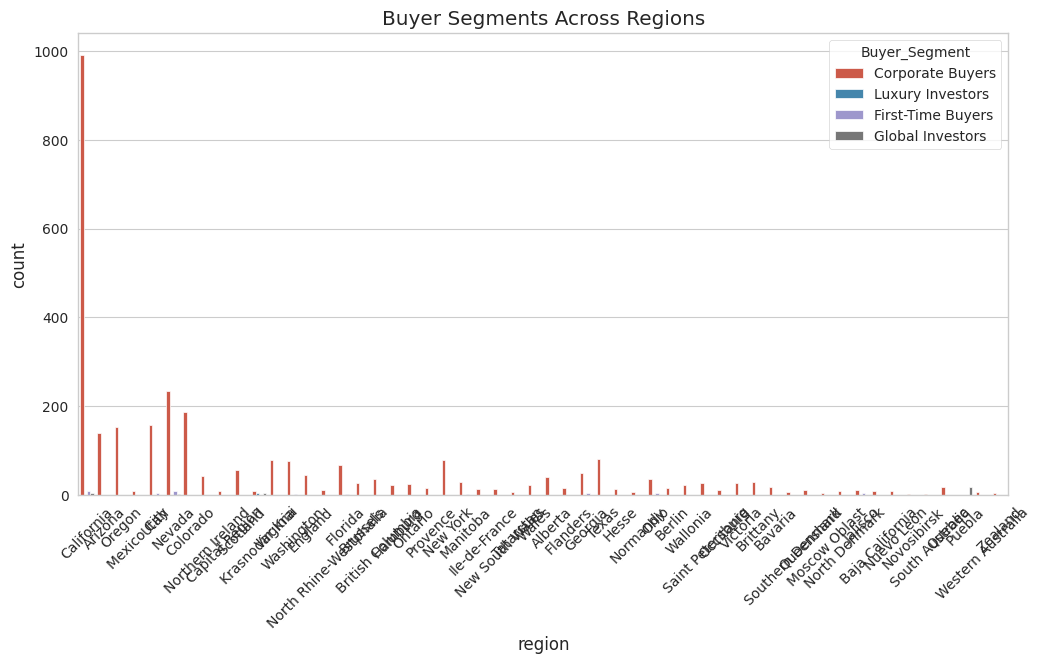

In [414]:
plot_data_temp_region = pd.DataFrame({
    'region': data.loc[df.index, 'region'],
    'Buyer_Segment': df['Buyer_Segment']
})

plt.figure(figsize=(12,6))

sns.countplot(
    data=plot_data_temp_region,
    x="region",
    hue="Buyer_Segment"
)

plt.xticks(rotation=45)

plt.title("Buyer Segments Across Regions")

plt.show()

In [415]:
plot_data_temp_country = pd.DataFrame({
    'country': data.loc[df.index, 'country'],
    'Buyer_Segment': df['Buyer_Segment']
})

country_segment = pd.crosstab(
    plot_data_temp_country["country"],
    plot_data_temp_country["Buyer_Segment"]
)
country_segment

Buyer_Segment,Corporate Buyers,First-Time Buyers,Global Investors,Luxury Investors
country,,,,
Australia,62,0,0,0
Belgium,64,0,0,0
Canada,150,3,0,0
Denmark,27,0,0,0
France,74,0,0,0
Germany,81,0,0,0
Mexico,41,4,18,0
Russia,48,0,5,4
UK,166,0,0,0


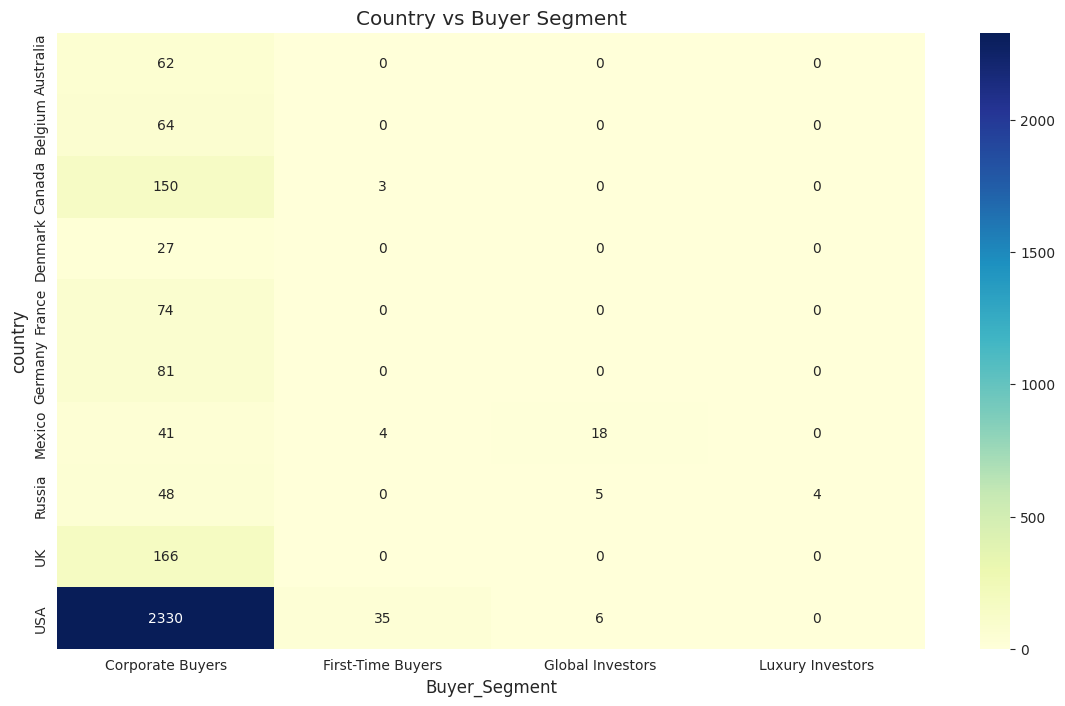

In [416]:
plot_data_temp_country = pd.DataFrame({
    'country': data.loc[df.index, 'country'],
    'Buyer_Segment': df['Buyer_Segment']
})

country_segment = pd.crosstab(
    plot_data_temp_country["country"],
    plot_data_temp_country["Buyer_Segment"]
)

plt.figure(figsize=(14,8))

sns.heatmap(

    country_segment,

    annot=True,

    cmap="YlGnBu",

    fmt="d"

)

plt.title("Country vs Buyer Segment")

plt.show()

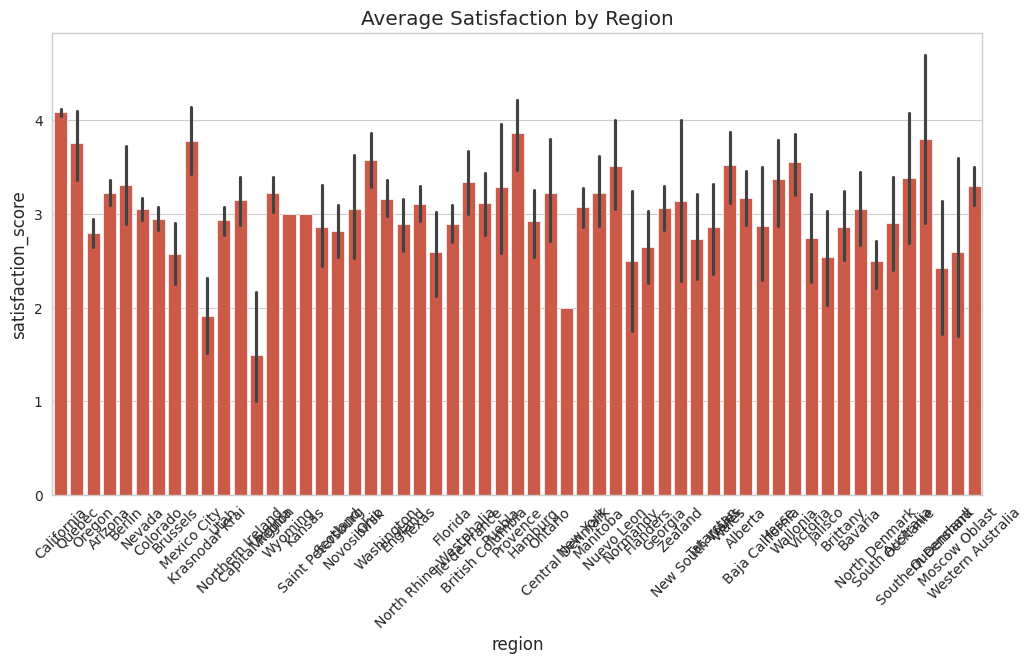

In [417]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=data,

    x="region",

    y="satisfaction_score"

)

plt.xticks(rotation=45)

plt.title("Average Satisfaction by Region")

plt.show()

In [418]:
loan_region = pd.crosstab(

    data["region"],

    data["loan_applied"]

)

loan_region

loan_applied,No,Yes
region,,
Alberta,40,51
Arizona,247,137
Baja California,21,3
Bavaria,22,18
Berlin,26,10
British Columbia,52,21
Brittany,39,18
Brussels,36,15
California,4231,863


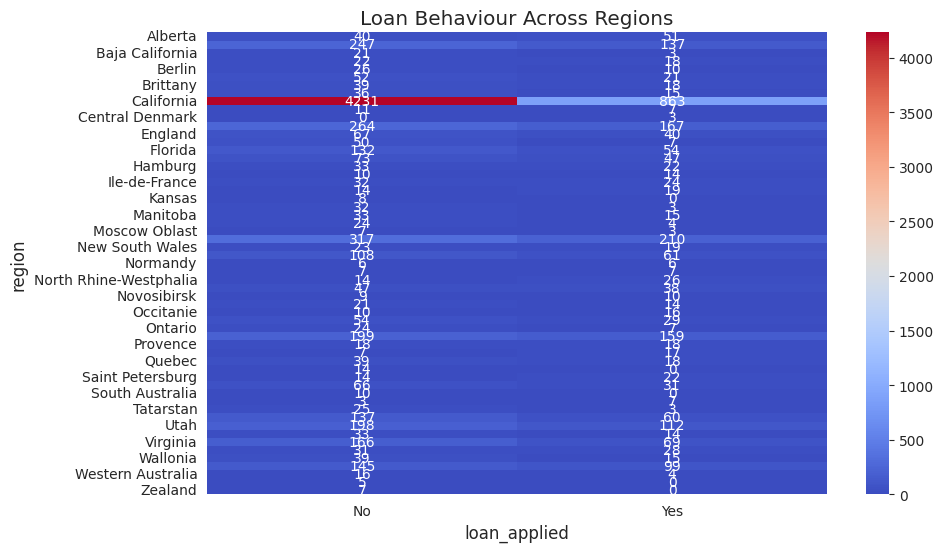

In [419]:
plt.figure(figsize=(10,6))

sns.heatmap(

    loan_region,

    annot=True,

    cmap="coolwarm",

    fmt="d"

)

plt.title("Loan Behaviour Across Regions")

plt.show()

In [420]:
investor_dashboard = df.groupby("Buyer_Segment").agg({

    "Age":"mean",

    "satisfaction_score":"mean",

    "Buyer_Segment":"count" # Using Buyer_Segment with 'count' to count rows in each group

})

investor_dashboard.rename(columns={

    "Buyer_Segment":"Total Clients" # Renaming to reflect the count of clients

}, inplace=True)

investor_dashboard

,Age,satisfaction_score,Total Clients
Buyer_Segment,,,
Corporate Buyers,55.651988,3.041407,3043
First-Time Buyers,57.976190,3.095238,42
Global Investors,48.689655,3.206897,29
Luxury Investors,71.000000,3.000000,4


In [421]:
kpi = pd.DataFrame({

    "Metric":[

        "Total Buyers",

        "Total Segments",

        "Average Age",

        "Average Satisfaction"

    ],

    "Value":[

        len(df),

        df["Buyer_Segment"].nunique(),

        round(df["Age"].mean(),2),

        round(df["satisfaction_score"].mean(),2)

    ]

})

kpi

,Metric,Value
0,Total Buyers,3118.00
1,Total Segments,4.00
2,Average Age,55.64
3,Average Satisfaction,3.04


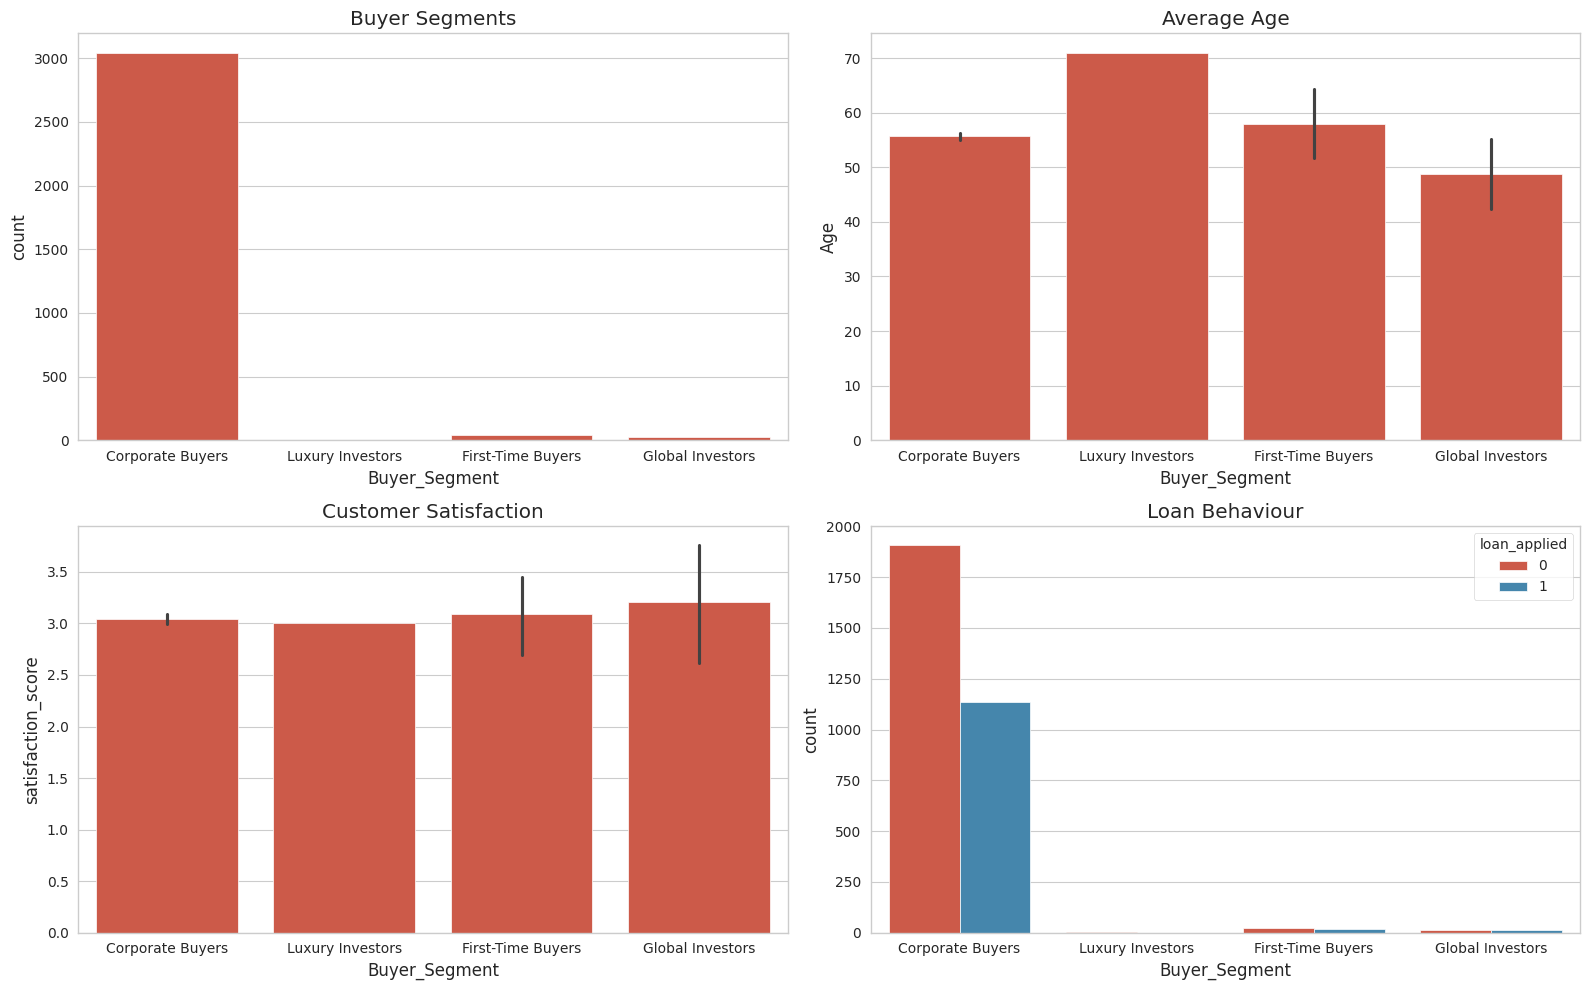

In [422]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

sns.countplot(

    data=df,

    x="Buyer_Segment",

    ax=ax[0,0]

)

ax[0,0].set_title("Buyer Segments")

sns.barplot(

    data=df,

    x="Buyer_Segment",

    y="Age",

    ax=ax[0,1]

)

ax[0,1].set_title("Average Age")

sns.barplot(

    data=df,

    x="Buyer_Segment",

    y="satisfaction_score",

    ax=ax[1,0]

)

ax[1,0].set_title("Customer Satisfaction")

sns.countplot(

    data=df,

    x="Buyer_Segment",

    hue="loan_applied",

    ax=ax[1,1]

)

ax[1,1].set_title("Loan Behaviour")

plt.tight_layout()

plt.show()

In [423]:
segment_summary.to_csv(
    "buyer_segment_summary.csv",
    index=True
)

investor_dashboard.to_csv(
    "investor_dashboard.csv"
)

print("Business reports exported successfully.")

Business reports exported successfully.


In [424]:
print("="*70)

print("BUSINESS RECOMMENDATIONS")

print("="*70)

for segment in df["Buyer_Segment"].unique():

    print()

    print(segment)

    subset = df[df["Buyer_Segment"]==segment]

    print("-"*50)

    print("Average Age :", round(subset["Age"].mean(),1))

    print("Average Satisfaction :", round(subset["satisfaction_score"].mean(),2))

    print("Top Region :", data.loc[subset.index,"region"].mode()[0])

    print("Top Country :", data.loc[subset.index,"country"].mode()[0])

    print("Top Client Type :", data.loc[subset.index,"client_type"].mode()[0])

    print("Top Acquisition Purpose :", data.loc[subset.index,"acquisition_purpose"].mode()[0])

    print("Recommended Marketing Strategy:")

    if subset["loan_applied"].mode()[0] == 1: # 1 represents "Yes" after Label Encoding

        print("Offer flexible financing options and loan assistance.")

    else:

        print("Promote premium and investment-focused properties.")

BUSINESS RECOMMENDATIONS

Corporate Buyers
--------------------------------------------------
Average Age : 55.7
Average Satisfaction : 3.04
Top Region : California
Top Country : USA
Top Client Type : Individual
Top Acquisition Purpose : Home
Recommended Marketing Strategy:
Promote premium and investment-focused properties.

Luxury Investors
--------------------------------------------------
Average Age : 71.0
Average Satisfaction : 3.0
Top Region : Krasnodar Krai
Top Country : Russia
Top Client Type : Individual
Top Acquisition Purpose : Investment
Recommended Marketing Strategy:
Promote premium and investment-focused properties.

First-Time Buyers
--------------------------------------------------
Average Age : 58.0
Average Satisfaction : 3.1
Top Region : California
Top Country : USA
Top Client Type : Individual
Top Acquisition Purpose : Home
Recommended Marketing Strategy:
Promote premium and investment-focused properties.

Global Investors
------------------------------------------

In [425]:
data.to_csv(

    "RealEstate_Buyer_Intelligence.csv",

    index=False

)

print("Final Business Intelligence Dataset Saved Successfully.")

Final Business Intelligence Dataset Saved Successfully.


In [426]:
import joblib

joblib.dump(kmeans,"kmeans_model.pkl")

print("KMeans Model Saved Successfully")

KMeans Model Saved Successfully


In [427]:
joblib.dump(scaler,"scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [428]:
joblib.dump(pca,"pca_model.pkl")

print("PCA Model Saved")

PCA Model Saved
